In [88]:
import pandas as pd
import numpy as np
import seaborn as sns
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


In [89]:
dataset=pd.read_csv("dataset/JED_Cargo_Export_Dataset.csv")
dataset

,Date,Year,Month,Season,Origin,Destination,Flight_Type,Flight_ID,Aircraft_Type,Shipment_Count,...,ULD_Type,Pallet_Count,Nature_of_Goods,Cargo_Mix_Complexity,Manpower_Assigned,Forklift_Count,Equipment_Availability,Shift,Weather_Condition,Build_Up_Time_Minutes
0,2024-06-01,2024,6,Hajj,JED,AMS,International,SV2587,B787-9,301,...,PMC,3,Automotive Parts,Low,12,3,Medium,Afternoon,Clear,260.4
1,2024-06-01,2024,6,Hajj,JED,CAN,International,TK5150,B737-800,239,...,PAG,0,Mail,Low,8,1,Medium,Afternoon,Storm,152.2
2,2024-06-01,2024,6,Hajj,JED,CAI,International,EK7092,A321,154,...,PMC,1,General Cargo,Low,9,2,Medium,Morning,Clear,124.2
3,2024-06-01,2024,6,Hajj,JED,DMM,Domestic,QR3059,A320,230,...,PMC,2,General Cargo,Low,8,2,Low,Morning,Clear,179.9
4,2024-06-01,2024,6,Hajj,JED,CDG,International,GF1237,B777F,354,...,PMC,4,Seafood,High,11,3,Medium,Afternoon,Clear,283.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,2026-05-31,2026,5,Hajj,JED,DXB,International,GF3221,B777F,474,...,PAG,3,E-commerce,High,12,2,Medium,Afternoon,Clear,286.1
29996,2026-05-31,2026,5,Hajj,JED,DMM,Domestic,SV8190,B737-800,117,...,AKE,0,Seafood,Medium,8,2,Medium,Morning,Rain,107.2
29997,2026-05-31,2026,5,Hajj,JED,IST,International,QR4590,B787-9,355,...,PMC,2,E-commerce,Medium,7,3,Medium,Afternoon,Clear,216.3
29998,2026-05-31,2026,5,Hajj,JED,CAI,International,EK3736,B787-9,275,...,AKE,3,Fresh Produce,High,11,1,Medium,Night,Clear,253.1


**3.Basic Checkups**


In [90]:
# Shape
print("Shape of the dataset:")
print(dataset.shape)
print("\n")

# Columns
print("Columns in the dataset:")
print(dataset.columns)
print("\n")

#check the null values in the dataset
print("Null values in the dataset:")
print(dataset.isnull().sum())



Shape of the dataset:
(30000, 23)


Columns in the dataset:
Index(['Date', 'Year', 'Month', 'Season', 'Origin', 'Destination',
       'Flight_Type', 'Flight_ID', 'Aircraft_Type', 'Shipment_Count',
       'Cargo_Weight_KG', 'Cargo_Volume_CBM', 'ULD_Count', 'ULD_Type',
       'Pallet_Count', 'Nature_of_Goods', 'Cargo_Mix_Complexity',
       'Manpower_Assigned', 'Forklift_Count', 'Equipment_Availability',
       'Shift', 'Weather_Condition', 'Build_Up_Time_Minutes'],
      dtype='str')


Null values in the dataset:
Date                      0
Year                      0
Month                     0
Season                    0
Origin                    0
Destination               0
Flight_Type               0
Flight_ID                 0
Aircraft_Type             0
Shipment_Count            0
Cargo_Weight_KG           0
Cargo_Volume_CBM          0
ULD_Count                 0
ULD_Type                  0
Pallet_Count              0
Nature_of_Goods           0
Cargo_Mix_Complexity      0
Manpow

In [91]:
# Information about the dataset
print("Dataset Information:")
dataset.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    30000 non-null  str    
 1   Year                    30000 non-null  int64  
 2   Month                   30000 non-null  int64  
 3   Season                  30000 non-null  str    
 4   Origin                  30000 non-null  str    
 5   Destination             30000 non-null  str    
 6   Flight_Type             30000 non-null  str    
 7   Flight_ID               30000 non-null  str    
 8   Aircraft_Type           30000 non-null  str    
 9   Shipment_Count          30000 non-null  int64  
 10  Cargo_Weight_KG         30000 non-null  float64
 11  Cargo_Volume_CBM        30000 non-null  float64
 12  ULD_Count               30000 non-null  int64  
 13  ULD_Type                30000 non-null  str    
 14  Pallet_Count            3000

In [92]:
#statistical summary of the dataset
print("Statistical Summary of the Dataset:")
dataset.describe()

Statistical Summary of the Dataset:


,Year,Month,Shipment_Count,Cargo_Weight_KG,Cargo_Volume_CBM,ULD_Count,Pallet_Count,Manpower_Assigned,Forklift_Count,Build_Up_Time_Minutes
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000
mean,2024.957500,6.475067,262.706700,8680.180063,36.063727,5.621633,2.084333,9.353900,2.33280,199.893917
std,0.702598,3.536457,91.469746,7635.758745,31.046336,3.665759,1.926952,3.196914,1.07304,61.797376
min,2024.000000,1.000000,20.000000,500.000000,5.000000,1.000000,0.000000,2.000000,1.00000,30.000000
25%,2024.000000,3.000000,193.000000,2875.650000,14.620000,3.000000,1.000000,7.000000,1.00000,153.600000
50%,2025.000000,6.000000,271.000000,6506.750000,27.190000,5.000000,2.000000,9.000000,2.00000,197.100000
75%,2025.000000,10.000000,327.000000,12383.550000,47.982500,8.000000,3.000000,12.000000,3.00000,241.600000
max,2026.000000,12.000000,568.000000,50000.000000,302.590000,32.000000,18.000000,22.000000,8.00000,470.400000


**4. Exploratory Data Analysis**

4.1 Target Distribution

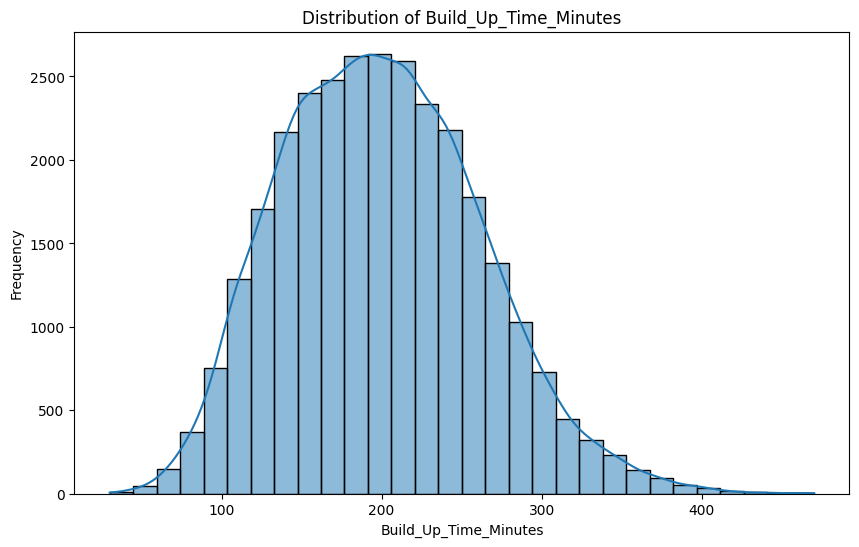

In [93]:
target_column = "Build_Up_Time_Minutes"
plt.figure(figsize=(10,6))

sns.histplot(
    dataset[target_column],
    bins=30,
    kde=True
)

plt.title(
    f"Distribution of {target_column}"
)

plt.xlabel(target_column)

plt.ylabel("Frequency")

plt.show()

4.2 Weight vs Build-Up Time

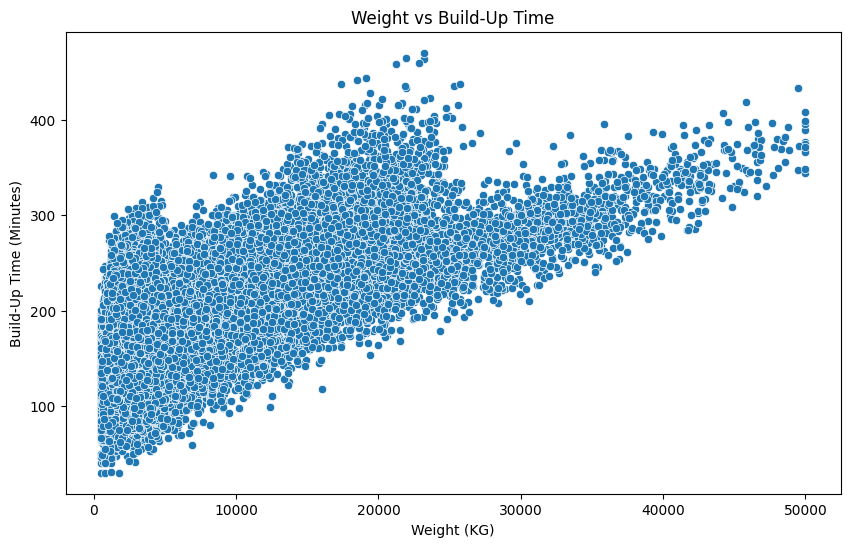

In [94]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=dataset,
    x='Cargo_Weight_KG',
    y='Build_Up_Time_Minutes'
)

plt.title('Weight vs Build-Up Time')
plt.xlabel('Weight (KG)')
plt.ylabel('Build-Up Time (Minutes)')

plt.show()

4.3 Distribution for Important Feature

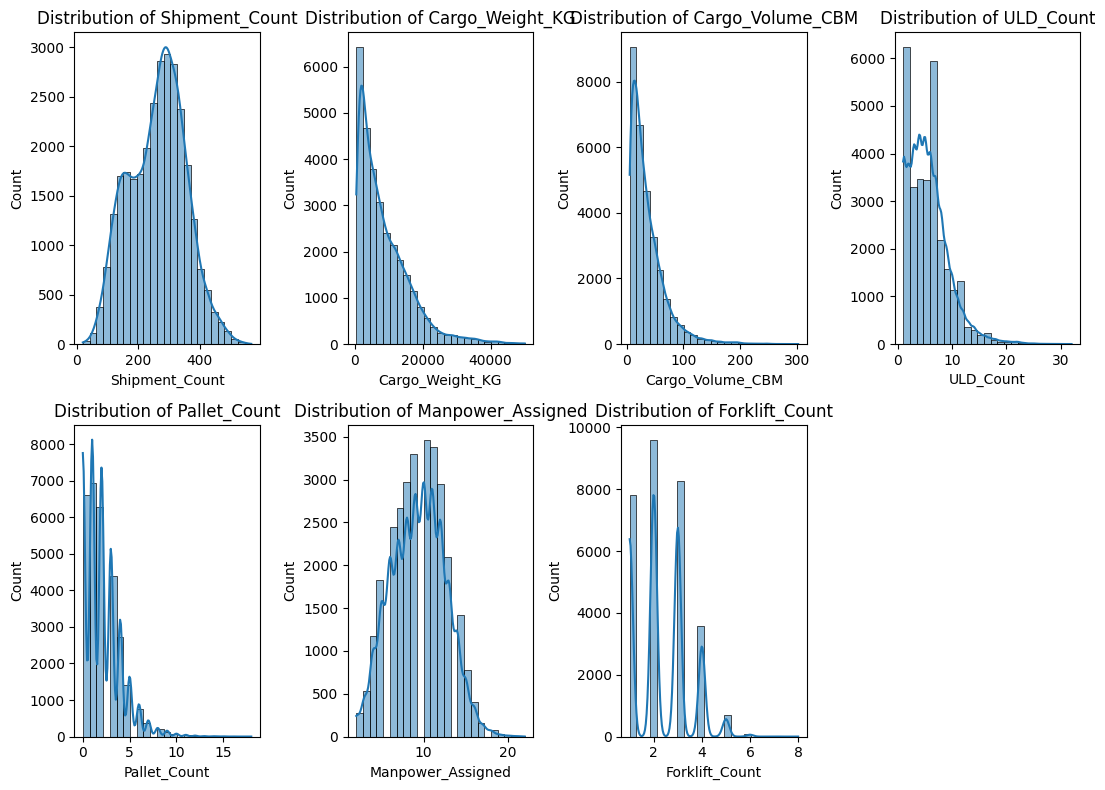

In [95]:
features = [
    "Shipment_Count",
    "Cargo_Weight_KG",
    "Cargo_Volume_CBM",
    "ULD_Count",
    "Pallet_Count",
    "Manpower_Assigned",
    "Forklift_Count"
]

n_cols = 4
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(11, n_rows * 4)
)

axes = axes.flatten()
for i, feature in enumerate(features):
    sns.histplot(
        dataset[feature],
        bins=25,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(
        f"Distribution of {feature}"
    )
    axes[i].set_xlabel(
        feature
    )
    axes[i].set_ylabel(
        "Count"
    )

# Hide unused plots
for j in range(len(features), len(axes)):
    axes[j].axis("off")

plt.tight_layout()

plt.show()

4.4 Handling Sweked Data

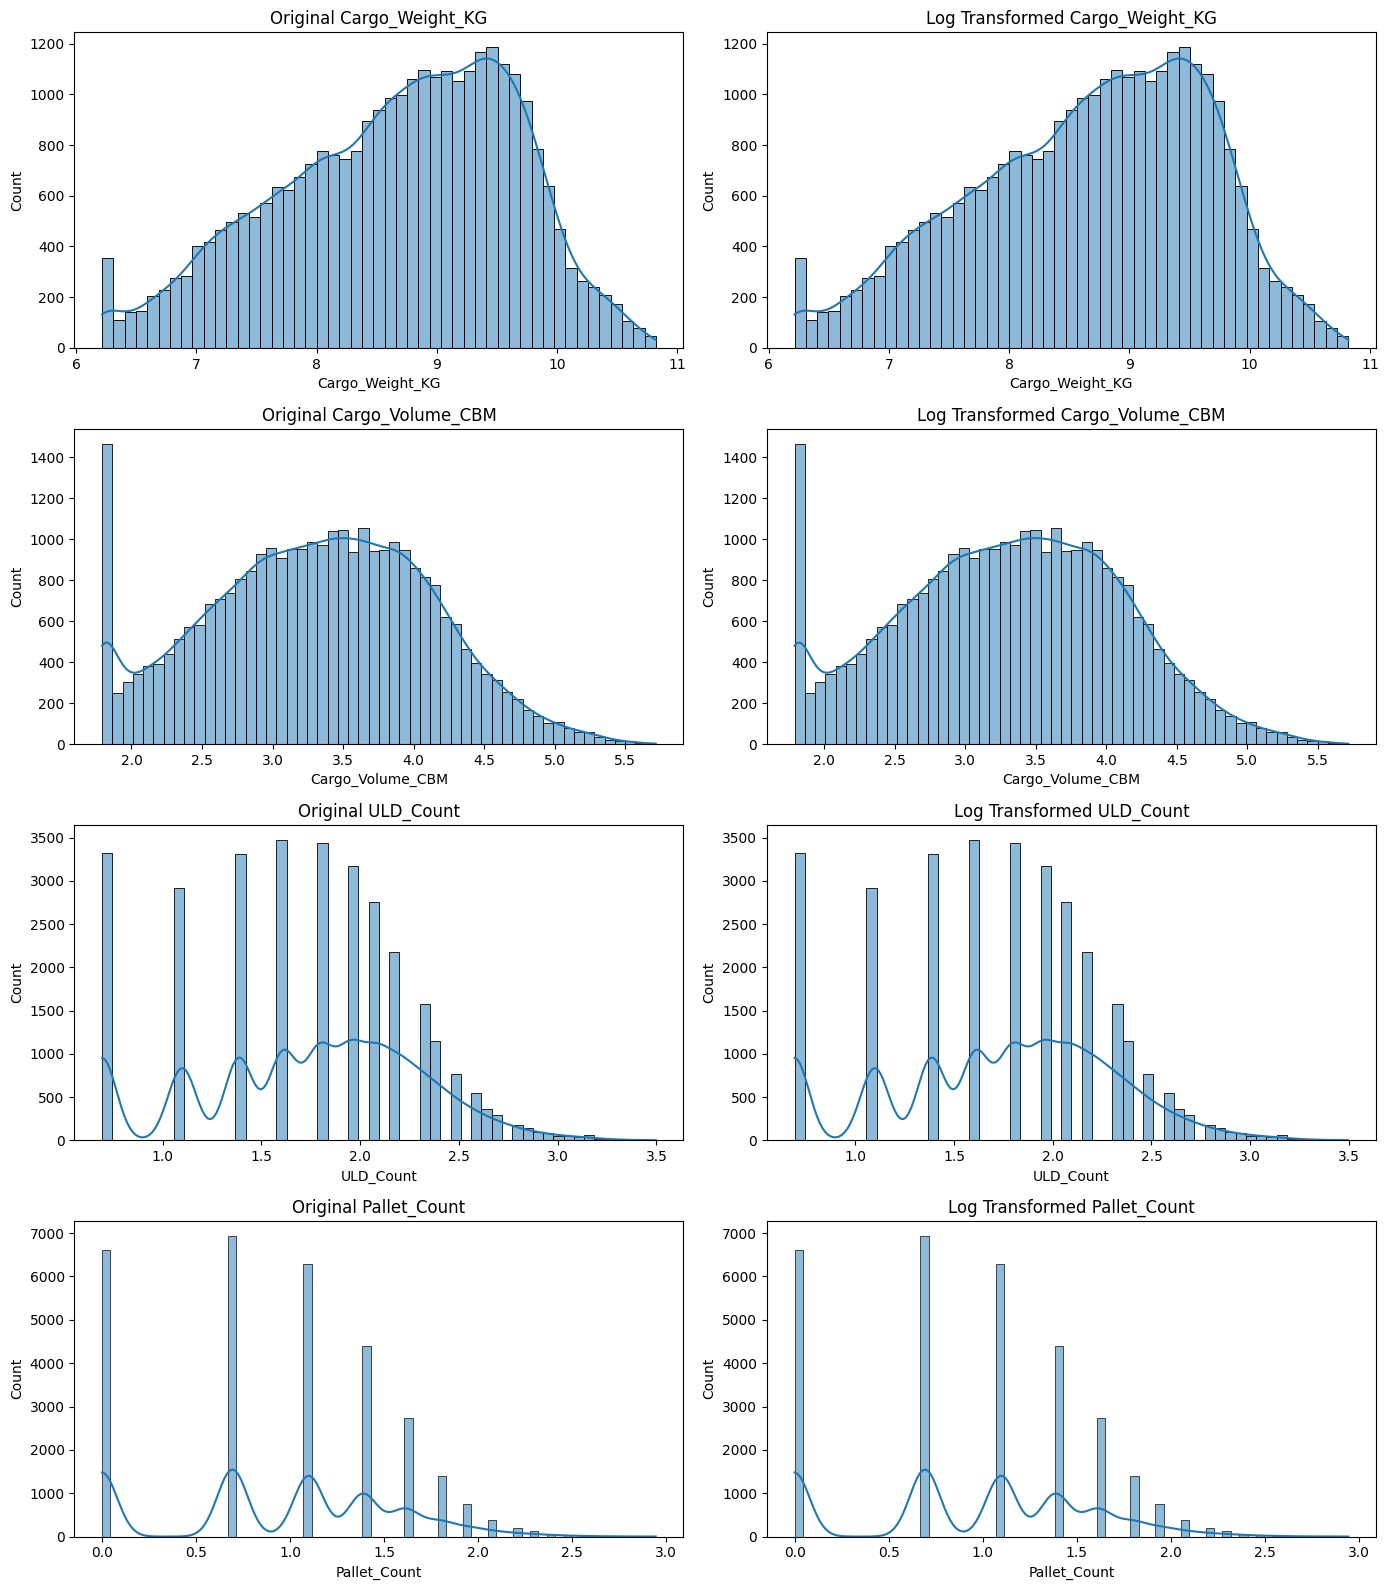

In [96]:
dataset["Cargo_Weight_KG"] = np.log1p(
    dataset["Cargo_Weight_KG"]
)

dataset["Cargo_Volume_CBM"] = np.log1p(
    dataset["Cargo_Volume_CBM"]
)

dataset["ULD_Count"] = np.log1p(
    dataset["ULD_Count"]
)

dataset["Pallet_Count"] = np.log1p(
    dataset["Pallet_Count"]
)

fig, axes = plt.subplots(
    4,
    2,
    figsize=(14,16)
)

features = [
    "Cargo_Weight_KG",
    "Cargo_Volume_CBM",
    "ULD_Count",
    "Pallet_Count",    
]

for i, feature in enumerate(features):

    sns.histplot(
        dataset[feature],
        kde=True,
        ax=axes[i,0]
    )

    axes[i,0].set_title(
        f"Original {feature}"
    )

    sns.histplot(
        dataset[feature],
        kde=True,
        ax=axes[i,1]
    )

    axes[i,1].set_title(
        f"Log Transformed {feature}"
    )

plt.tight_layout()
plt.show()

4.5 Distribution for Categorical Column


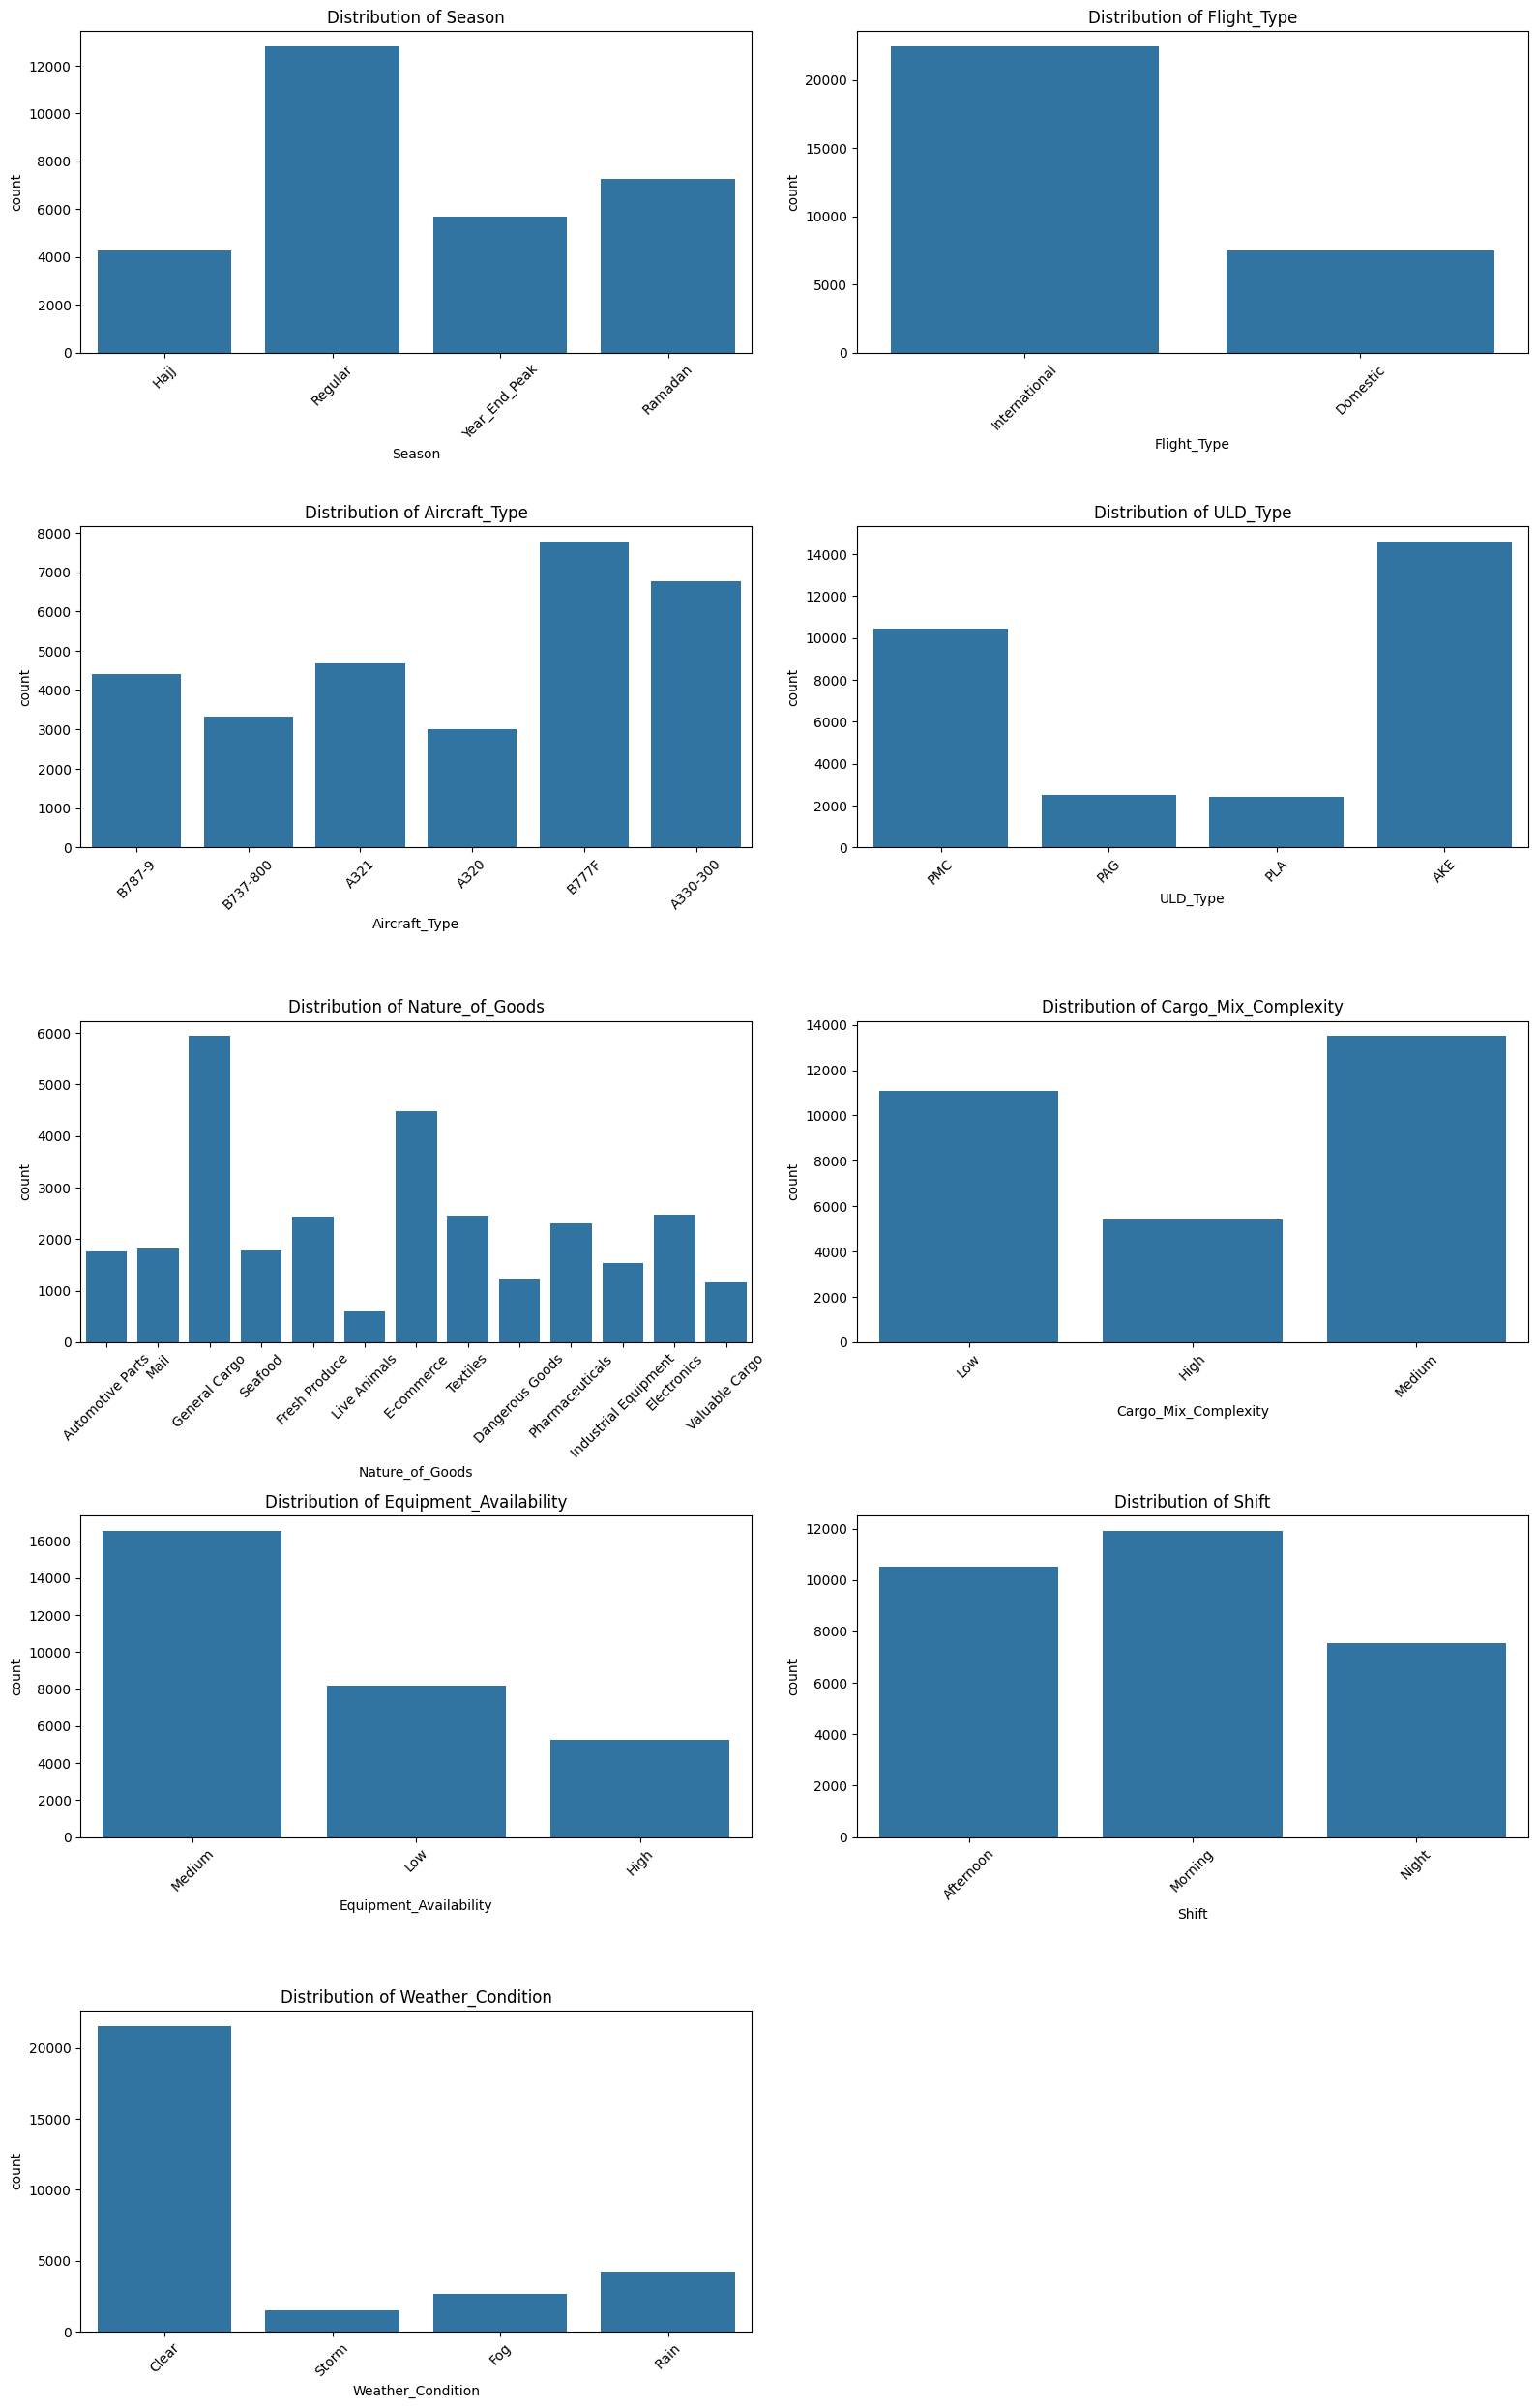

In [97]:
categorical_cols = [
    "Season",
    "Flight_Type",
    "Aircraft_Type",
    "ULD_Type",
    "Nature_of_Goods",
    "Cargo_Mix_Complexity",
    "Equipment_Availability",
    "Shift",
    "Weather_Condition"
]

n_cols = 2
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, n_rows * 5)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    sns.countplot(
        data=dataset,
        x=col,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Distribution of {col}"
    )

    axes[i].tick_params(
        axis='x',
        rotation=45
    )

# Hide empty plots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

**5. Feature Engineering**

5.1 Data Splitting

In [98]:
# Features and Target

drop_columns = [
    'Build_Up_Time_Minutes',
    'Date',
    'Flight_ID'
]

X = dataset.drop(
    drop_columns,
    axis=1
)
y = dataset[
    'Build_Up_Time_Minutes'
]

# Train 70%
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


# Validation 15%
# Test 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Train :", X_train.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)

Train : (21000, 20)
Validation : (4500, 20)
Test : (4500, 20)


In [99]:
# Backup for CatBoost

X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

y_train_cat = y_train.copy()
y_val_cat = y_val.copy()
y_test_cat = y_test.copy()

In [100]:
X_train_cat.info()

<class 'pandas.DataFrame'>
Index: 21000 entries, 28465 to 23654
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    21000 non-null  int64  
 1   Month                   21000 non-null  int64  
 2   Season                  21000 non-null  str    
 3   Origin                  21000 non-null  str    
 4   Destination             21000 non-null  str    
 5   Flight_Type             21000 non-null  str    
 6   Aircraft_Type           21000 non-null  str    
 7   Shipment_Count          21000 non-null  int64  
 8   Cargo_Weight_KG         21000 non-null  float64
 9   Cargo_Volume_CBM        21000 non-null  float64
 10  ULD_Count               21000 non-null  float64
 11  ULD_Type                21000 non-null  str    
 12  Pallet_Count            21000 non-null  float64
 13  Nature_of_Goods         21000 non-null  str    
 14  Cargo_Mix_Complexity    21000 non-null  str    
 1

5.2 Encoding the categorical value

In [101]:
# Categorical Columns

categorical_cols = X_train.select_dtypes(
    include='object'
).columns

print(categorical_cols)

Index(['Season', 'Origin', 'Destination', 'Flight_Type', 'Aircraft_Type',
       'ULD_Type', 'Nature_of_Goods', 'Cargo_Mix_Complexity',
       'Equipment_Availability', 'Shift', 'Weather_Condition'],
      dtype='str')


C:\Users\BalajiChitrarasu\AppData\Local\Temp\ipykernel_29440\914520902.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


In [102]:
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(
        X_train[col]
    )
    X_val[col] = le.transform(
        X_val[col]
    )
    X_test[col] = le.transform(
        X_test[col]
    )
    label_encoders[col] = le

In [103]:
X_train

,Year,Month,Season,Origin,Destination,Flight_Type,Aircraft_Type,Shipment_Count,Cargo_Weight_KG,Cargo_Volume_CBM,ULD_Count,ULD_Type,Pallet_Count,Nature_of_Goods,Cargo_Mix_Complexity,Manpower_Assigned,Forklift_Count,Equipment_Availability,Shift,Weather_Condition
28465,2026,4,1,0,15,1,1,175,8.046677,2.324347,0.693147,0,0.000000,5,1,7,1,2,1,2
27622,2026,4,1,0,7,1,2,305,9.714643,4.509760,2.564949,2,1.098612,10,0,10,4,0,2,2
28376,2026,4,1,0,10,1,4,335,9.863748,4.718767,2.484907,0,1.791759,7,0,10,3,2,0,0
10917,2025,3,1,0,17,1,3,231,6.731495,1.791759,0.693147,0,0.693147,8,2,6,1,0,0,3
27234,2026,4,1,0,11,1,4,374,9.450302,3.586293,2.079442,0,0.693147,3,2,13,4,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,2026,5,0,0,19,1,4,414,8.047925,2.654649,1.609438,3,1.386294,8,2,11,2,2,2,1
5390,2024,11,3,0,18,0,1,299,6.935079,1.809927,0.693147,0,0.693147,8,1,6,2,2,1,2
860,2024,6,0,0,5,1,2,271,8.546247,3.054001,2.079442,0,1.386294,5,1,12,3,1,0,0
15795,2025,6,0,0,17,1,5,326,8.847575,3.183870,1.791759,0,1.098612,5,1,10,2,2,2,0


5.3 Scaling the numeric value

In [104]:
numerical_cols = X_train.columns

print(numerical_cols)

Index(['Year', 'Month', 'Season', 'Origin', 'Destination', 'Flight_Type',
       'Aircraft_Type', 'Shipment_Count', 'Cargo_Weight_KG',
       'Cargo_Volume_CBM', 'ULD_Count', 'ULD_Type', 'Pallet_Count',
       'Nature_of_Goods', 'Cargo_Mix_Complexity', 'Manpower_Assigned',
       'Forklift_Count', 'Equipment_Availability', 'Shift',
       'Weather_Condition'],
      dtype='str')


In [105]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train_scaled[numerical_cols]
)

X_val_scaled[numerical_cols] = scaler.transform(
    X_val_scaled[numerical_cols]
)

X_test_scaled[numerical_cols] = scaler.transform(
    X_test_scaled[numerical_cols]
)

In [106]:
X_train_scaled.head()

,Year,Month,Season,Origin,Destination,Flight_Type,Aircraft_Type,Shipment_Count,Cargo_Weight_KG,Cargo_Volume_CBM,ULD_Count,ULD_Type,Pallet_Count,Nature_of_Goods,Cargo_Mix_Complexity,Manpower_Assigned,Forklift_Count,Equipment_Availability,Shift,Weather_Condition
28465,1.484382,-0.705747,-0.705384,0.0,0.833924,0.579476,-1.080309,-0.957399,-0.631516,-1.260358,-1.851183,-0.942159,-1.502981,-0.148173,-0.365663,-0.733818,-1.241064,0.813232,0.130677,1.607893
27622,1.484382,-0.705747,-0.705384,0.0,-0.552950,0.579476,-0.450741,0.466138,1.076151,1.516775,1.456733,0.517313,0.252241,1.302475,-1.706727,0.202762,1.555625,-1.791691,1.429405,1.607893
28376,1.484382,-0.705747,-0.705384,0.0,-0.032872,0.579476,0.808396,0.794646,1.228806,1.782372,1.315279,-0.942159,1.359662,0.432086,-1.706727,0.202762,0.623395,0.813232,-1.168051,-0.571738
10917,0.061457,-0.988558,-0.705384,0.0,1.180643,0.579476,0.178827,-0.344183,-1.978003,-1.937148,-1.851183,-0.942159,-0.395559,0.722216,0.975400,-1.046011,-1.241064,-1.791691,-1.168051,2.697708
27234,1.484382,-0.705747,-0.705384,0.0,0.140487,0.579476,0.808396,1.221707,0.805518,0.343271,0.598726,-0.942159,-0.395559,-0.728433,0.975400,1.139342,1.555625,0.813232,0.130677,1.607893


**6. Model Building**

6.1 Linear Regression

In [107]:
# Initialize Model
lr_model = LinearRegression()
lr_model.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = lr_model.predict(
    X_val_scaled
)

print(
    "Linear Regression Model Trained Successfully"
)

Linear Regression Model Trained Successfully


In [108]:
# MAE
lr_mae = mean_absolute_error(y_val, y_pred_lr)

# MSE
lr_mse = mean_squared_error(y_val, y_pred_lr)

# RMSE
lr_rmse = np.sqrt(lr_mse)

# R2
lr_r2 = r2_score(y_val, y_pred_lr)

print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE :", lr_rmse)
print("R2 Score :", lr_r2)

MAE : 20.117207867833603
MSE : 654.6892052639424
RMSE : 25.58689518608974
R2 Score : 0.8327736842387188


6.2 Decision Tree Regressor

In [109]:
# dt_param_grid = {
#     'max_depth': [5, 10, 15, 20],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2']
# }

# dt_grid = GridSearchCV(
#     estimator=DecisionTreeRegressor(
#         random_state=42
#     ),
#     param_grid=dt_param_grid,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# dt_grid.fit(
#     X_train,
#     y_train
# )

# print("Best Parameters:")
# print(dt_grid.best_params_)

# print("\nBest Score:")
# print(dt_grid.best_score_)

In [110]:
dt_model = DecisionTreeRegressor(
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

y_pred_dt = dt_model.predict(
    X_val
)

print(
    "Decision Tree Regressor Trained Successfully"
)

Decision Tree Regressor Trained Successfully


In [111]:
dt_mae = mean_absolute_error(
    y_val,
    y_pred_dt
)

dt_mse = mean_squared_error(
    y_val,
    y_pred_dt
)

dt_rmse = np.sqrt(
    dt_mse
)

dt_r2 = r2_score(
    y_val,
    y_pred_dt
)

print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE :", dt_rmse)
print("R2 Score :", dt_r2)

MAE : 18.711234986001653
MSE : 557.541296091473
RMSE : 23.612312383404404
R2 Score : 0.8575880340159907


6.3 Random Forest Regressor

In [112]:
# rf_param_grid = {
#     'n_estimators': [100, 200, 300, 500],
#     'max_depth': [5, 10, 15, 20, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2']
# }

# rf_random = RandomizedSearchCV(
#     estimator=RandomForestRegressor(
#         random_state=42
#     ),
#     param_distributions=rf_param_grid,
#     n_iter=20,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# rf_random.fit(
#     X_train,
#     y_train
# )

# print("Best Parameters:")
# print(
#     rf_random.best_params_
# )
# print("\nBest Score:")
# print(
#     rf_random.best_score_
# )

In [113]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='log2',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(
    X_val
)

print(
    "Random Forest Regressor Trained Successfully"
)

Random Forest Regressor Trained Successfully


In [114]:
rf_mae = mean_absolute_error(y_val,  y_pred_rf)
rf_mse = mean_squared_error(y_val, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_val, y_pred_rf)

print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE :", rf_rmse)
print("R2 Score :", rf_r2)

MAE : 12.972838474480367
MSE : 269.04586344305017
RMSE : 16.402617579003973
R2 Score : 0.9312780046583242


6.4 XGBoost Regressor

In [115]:
# xgb_param_grid = {
#     'n_estimators': [100, 200, 300, 500],
#     'max_depth': [3, 5, 7, 10],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'subsample': [0.8, 0.9, 1.0],
#     'colsample_bytree': [0.8, 0.9, 1.0],
#     'min_child_weight': [1, 3, 5]
# }

# xgb_random = RandomizedSearchCV(
#     estimator=XGBRegressor(
#         random_state=42
#     ),
#     param_distributions=xgb_param_grid,
#     n_iter=20,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# xgb_random.fit(
#     X_train,
#     y_train
# )

# print("Best Parameters:")
# print(
#     xgb_random.best_params_
# )

# print("\nBest Score:")
# print(
#     xgb_random.best_score_
# )

In [116]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=1,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb_model.predict(
    X_val
)

print(
    "XGBoost Regressor Trained Successfully"
)

XGBoost Regressor Trained Successfully


In [117]:
xgb_mae = mean_absolute_error(
    y_val,
    y_pred_xgb
)

xgb_mse = mean_squared_error(
    y_val,
    y_pred_xgb
)

xgb_rmse = np.sqrt(
    xgb_mse
)

xgb_r2 = r2_score(
    y_val,
    y_pred_xgb
)

print("MAE :", xgb_mae)
print("MSE :", xgb_mse)
print("RMSE :", xgb_rmse)
print("R2 Score :", xgb_r2)

MAE : 8.571416235860188
MSE : 116.59688902752552
RMSE : 10.798003937187906
R2 Score : 0.9702178254589683


6.5 LightGBM Regressor

In [118]:
# lgbm_param_grid = {
#     'n_estimators': [100, 200, 300, 500],
#     'max_depth': [3, 5, 7, 10, 15],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'num_leaves': [15, 31, 63, 127],
#     'subsample': [0.8, 0.9, 1.0],
#     'colsample_bytree': [0.8, 0.9, 1.0]
# }

# lgbm_random = RandomizedSearchCV(
#     estimator=LGBMRegressor(
#         random_state=42,
#         verbose=-1
#     ),
#     param_distributions=lgbm_param_grid,
#     n_iter=20,
#     scoring='neg_mean_squared_error',
#     cv=5,
#     random_state=42,
#     n_jobs=-1
# )

# lgbm_random.fit(X_train,y_train)

# print("Best Parameters:")
# print(lgbm_random.best_params_)

# print("\nBest Score:")
# print(lgbm_random.best_score_)

In [119]:
lgbm_model = LGBMRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.1,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.9,
    random_state=42
)

lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_val)

print("LightGBM Regressor Trained Successfully")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 919
[LightGBM] [Info] Number of data points in the train set: 21000, number of used features: 19
[LightGBM] [Info] Start training from score 199.894681
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [120]:
lgbm_mae = mean_absolute_error(y_val,y_pred_lgbm)
lgbm_mse = mean_squared_error(y_val, y_pred_lgbm)
lgbm_rmse = np.sqrt(lgbm_mse)
lgbm_r2 = r2_score(y_val, y_pred_lgbm)

print("MAE :", lgbm_mae)
print("MSE :", lgbm_mse)
print("RMSE :", lgbm_rmse)
print("R2 Score :", lgbm_r2)

MAE : 8.585760579858137
MSE : 116.23206399292135
RMSE : 10.78109753192695
R2 Score : 0.9703110121893188


6.6 CatBoost Regressor

In [121]:
cat_features = X_train_cat.select_dtypes(
    include=['object','category']
).columns.tolist()

for col in cat_features:
    X_train_cat[col] = X_train_cat[col].astype('category')
    X_val_cat[col] = X_val_cat[col].astype('category')
    X_test_cat[col] = X_test_cat[col].astype('category')

C:\Users\BalajiChitrarasu\AppData\Local\Temp\ipykernel_29440\1892119016.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train_cat.select_dtypes(


In [122]:
# cat_param_grid = {
#     'iterations':[100,200,300,500],
#     'depth':[4,6,8,10],
#     'learning_rate':[0.01,0.05,0.1,0.2],
#     'l2_leaf_reg':[1,3,5,7,9]
# }

# cat_random = RandomizedSearchCV(
#     estimator=CatBoostRegressor(
#         random_state=42,
#         verbose=0
#     ),
#     param_distributions=cat_param_grid,
#     n_iter=20,
#     scoring='neg_mean_squared_error',
#     cv=5,
#     random_state=42,
#     n_jobs=-1
# )

# cat_random.fit(X_train_cat, y_train_cat,cat_features=cat_features)
# print("Best Parameters:")
# print(cat_random.best_params_)

# print("\nBest Score:")
# print(cat_random.best_score_)

In [123]:
cat_model = CatBoostRegressor(
    iterations=300,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=7,
    random_state=42,
    verbose=0
)

cat_model.fit(X_train_cat,y_train_cat,cat_features=cat_features)

y_pred_cat = cat_model.predict(X_val_cat)

print("CatBoost Regressor Trained Successfully")

CatBoost Regressor Trained Successfully


In [124]:
cat_mae = mean_absolute_error(y_val_cat, y_pred_cat)
cat_mse = mean_squared_error(y_val_cat, y_pred_cat)
cat_rmse = np.sqrt(cat_mse)
cat_r2 = r2_score(y_val_cat, y_pred_cat)

print("MAE :", cat_mae)
print("MSE :", cat_mse)
print("RMSE :", cat_rmse)
print("R2 Score :", cat_r2)

MAE : 8.421818485409714
MSE : 112.61061982515385
RMSE : 10.611815105115328
R2 Score : 0.971236032429521


**7. Model Comparision**

In [125]:
model_results = pd.DataFrame({
    'Model': ['Linear Regression','Decision Tree', 'Random Forest','XGBoost', 'LightGBM','CatBoost'],
    'MAE': [lr_mae, dt_mae, rf_mae, xgb_mae, lgbm_mae, cat_mae],
    'MSE': [lr_mse, dt_mse, rf_mse, xgb_mse, lgbm_mse, cat_mse],
    'RMSE': [lr_rmse, dt_rmse, rf_rmse, xgb_rmse, lgbm_rmse, cat_rmse],
    'R2 Score': [lr_r2, dt_r2, rf_r2, xgb_r2, lgbm_r2, cat_r2]
})

model_results = model_results.sort_values(
    by='R2 Score',
    ascending=False
)

model_results

,Model,MAE,MSE,RMSE,R2 Score
5,CatBoost,8.421818,112.610620,10.611815,0.971236
4,LightGBM,8.585761,116.232064,10.781098,0.970311
3,XGBoost,8.571416,116.596889,10.798004,0.970218
2,Random Forest,12.972838,269.045863,16.402618,0.931278
1,Decision Tree,18.711235,557.541296,23.612312,0.857588
0,Linear Regression,20.117208,654.689205,25.586895,0.832774


**8. Save the Model**

In [126]:
import joblib

joblib.dump(
    xgb_model,
    'models/build_up_time_model.pkl'
)
joblib.dump(
    X_train.columns.tolist(),
    'models/feature_columns.pkl'
)
joblib.dump(
    label_encoders,
    'models/label_encoders.pkl'
)

print("Label Encoders Saved")
print("Feature Columns Saved")
print("Model Saved Successfully")

Label Encoders Saved
Feature Columns Saved
Model Saved Successfully


**9. Test the model**

In [127]:
y_pred_test = cat_model.predict(X_test_cat)


test_mae = mean_absolute_error(y_test_cat,y_pred_test)
test_mse = mean_squared_error(y_test_cat, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test_cat,y_pred_test)


print("MAE :", test_mae)
print("MSE :", test_mse)
print("RMSE :", test_rmse)
print("R2 Score :", test_r2)


MAE : 8.369725493185378
MSE : 112.37125925369754
RMSE : 10.600531083568292
R2 Score : 0.9710503577814649


**9. Feature Importance**

In [128]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
10,ULD_Count,0.207714
9,Cargo_Volume_CBM,0.150355
7,Shipment_Count,0.143404
6,Aircraft_Type,0.104927
8,Cargo_Weight_KG,0.073014
14,Cargo_Mix_Complexity,0.070090
17,Equipment_Availability,0.066162
11,ULD_Type,0.039767
12,Pallet_Count,0.031251
19,Weather_Condition,0.030604
